# Chicago District Risk Classification
This notebook begins to explore the data from the ingestion notebook, with some inicial pre processing and feature engineering. Several dataframes are considered and their interconnections are explored then saved in the corresponding layers, usually silver and gold. We leave the exploratory data analysis, per se, to the next notebook. Here, we just understands our data and their relations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
from json import loads
import geopandas as gpd
from shapely.geometry import shape

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals


%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

# Entering Data
Originally, our interest was to consider as many datasets as possible from the Chicago Data Portal website. However, only the **Chicago Crime**, the **Police Stations** and the **Census**-like datasets have proven to be of real value to our project, since the information that can be retrieved from the remaining ones is almost non existent.

1. [Chicago Crime Dataset](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data)
2. [Police Stations](https://data.cityofchicago.org/Public-Safety/Police-Stations/z8bn-74gv/about_data)
3. [Census](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2/about_data)
4. [Arrests](https://data.cityofchicago.org/Public-Safety/Arrests/dpt3-jri9/about_data): not to be considered
5. [Fire Stations](https://data.cityofchicago.org/Public-Safety/Fire-Stations/28km-gtjn/about_data): not to be considered
6. [Sex Offenders](https://data.cityofchicago.org/Public-Safety/Sex-Offenders/vc9r-bqvy/about_data): not to be considered

## Pre-processing

### Police Stations

In [7]:
df_stations = pd.read_csv(f'{brz_path}/df_stations.csv')

df_stations = f.process_lat_lon(
    df_stations,
    orig_names=['lat', 'lon'],
    prefix='station_'
)

df_stations['district'] = df_stations['district'].astype(int).astype(str)

# df_stations['district'] = df_stations['district']\
#     .str.replace('Headquarters', '0')


# df_stations.to_csv(f'{slv_path}/df_stations.csv', index=False)
df_stations.head()

,district,district_name,station_lat,station_lon
0,0,Headquarters,41.830702,-87.623395
1,18,Near North,41.903242,-87.643352
2,19,Town Hall,41.947400,-87.651512
3,20,Lincoln,41.979550,-87.692845
4,22,Morgan Park,41.691435,-87.668520


In [8]:
# reading the pre processed data
df_stations = pd.read_csv(f'{slv_path}/df_stations.csv')

df_stations['district'] = df_stations['district'].astype(int).astype(str)

display(df_stations.info())

display(df_stations.head())

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   district       23 non-null     str    
 1   district_name  23 non-null     str    
 2   station_lat    23 non-null     float64
 3   station_lon    23 non-null     float64
dtypes: float64(2), str(2)
memory usage: 868.0 bytes


None

,district,district_name,station_lat,station_lon
0,0,Headquarters,41.830702,-87.623395
1,18,Near North,41.903242,-87.643352
2,19,Town Hall,41.947400,-87.651512
3,20,Lincoln,41.979550,-87.692845
4,22,Morgan Park,41.691435,-87.668520


### Community Area Census

The following data refers to the 2008-2012 period. Albeit not being the most recent data, we consider its use due to the fact that census data does not change considerably in a 10 year period.

- `percent_of_housing_crowded`: % occupied housing units with >1 person per room
- `percent_households_below_povery`: % of households living below the federal povery level
- `percent_aged_16_unemployed`: % of persons with age >16y that are unemployed
- `percent_aged_25_without_high_school_diploma`: % of persons with age >25y without a high school education
- `percent_aged_under_18_or_over_64`: % of the population with age <18y or >64y (dependents)
- `per_capita_income`: estimated as the sum of tract-level aggregated incomes divided by the total population
- `hardship_index`: score that incorporates each of the six sociooeconomic indicators above

In [9]:
df_census = pd.read_csv(f'{brz_path}/df_census.csv')

# there is a NaN value in the 'ca' column, as all others are present
# in the df_crime dataset, we shall drop it
df_census = df_census.dropna(subset=['ca'])

# making sure the percentages are in float type and in converting them to decimals
# aside from the per capita income column
for c in (
    'percent_of_housing_crowded',
    'percent_households_below_poverty',
    'percent_aged_16_unemployed',
    'percent_aged_25_without_high_school_diploma',
    'percent_aged_under_18_or_over_64',
    'per_capita_income_',
):
    if c != 'per_capita_income_':
        df_census[c] = df_census[c].astype(float) / 100
    else:
        df_census[c] = df_census[c].astype(float)

# score-like values, so we convert it to int
df_census['hardship_index'] = df_census['hardship_index'].astype(int)

df_census['ca'] = df_census['ca']\
    .astype(int)\
    .astype(str)

# renaming columns to more readable names
df_census = df_census.rename(
    columns={
        'ca': 'community_area',
        'percent_of_housing_crowded': 'pct_housing_crowded',
        'percent_households_below_poverty': 'pct_hh_below_pvty',
        'percent_aged_16_unemployed': 'pct_16_unemployed',
        'percent_aged_25_without_high_school_diploma': 'pct_25_without_hsd',
        'percent_aged_under_18_or_over_64': 'pct_dependents',
        'per_capita_income_': 'per_capita_income',
    }
)

# df_census.to_csv(f'{slv_path}/df_census.csv', index=False)
df_census

,community_area,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index
0,1,0.077,0.236,0.087,0.182,0.275,23939.0,39
1,2,0.078,0.172,0.088,0.208,0.385,23040.0,46
2,3,0.038,0.240,0.089,0.118,0.222,35787.0,20
3,4,0.034,0.109,0.082,0.134,0.255,37524.0,17
4,5,0.003,0.075,0.052,0.045,0.262,57123.0,6
...,...,...,...,...,...,...,...,...
72,73,0.011,0.169,0.208,0.137,0.426,19713.0,48
73,74,0.010,0.034,0.087,0.043,0.368,34381.0,16
74,75,0.008,0.132,0.150,0.108,0.403,27149.0,30
75,76,0.036,0.154,0.071,0.109,0.303,25828.0,24


In [10]:
# reading the pre processed data
df_census = pd.read_csv(f'{slv_path}/df_census.csv')
df_census['community_area'] = df_census['community_area'].astype(str)

display(df_census.info())
display(df_census.head())

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   community_area       77 non-null     str    
 1   pct_housing_crowded  77 non-null     float64
 2   pct_hh_below_pvty    77 non-null     float64
 3   pct_16_unemployed    77 non-null     float64
 4   pct_25_without_hsd   77 non-null     float64
 5   pct_dependents       77 non-null     float64
 6   per_capita_income    77 non-null     float64
 7   hardship_index       77 non-null     int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 4.9 KB


None

,community_area,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index
0,1,0.077,0.236,0.087,0.182,0.275,23939.0,39
1,2,0.078,0.172,0.088,0.208,0.385,23040.0,46
2,3,0.038,0.240,0.089,0.118,0.222,35787.0,20
3,4,0.034,0.109,0.082,0.134,0.255,37524.0,17
4,5,0.003,0.075,0.052,0.045,0.262,57123.0,6


### Crimes

In [72]:
df_crime = pd.read_csv(
    f'{brz_path}/df_crime.csv',
    index_col='date',
    parse_dates=True
)
df_crime = df_crime.sort_index()
df_crime = df_crime.drop_duplicates(subset='id')
df_crime['id'] = df_crime['id'].astype(str)
df_crime

,id,primary_type,arrest,domestic,district,community_area,latitude,longitude
date,,,,,,,,
2022-01-01 00:00:00,14135568,OFFENSE INVOLVING CHILDREN,False,True,4,46.0,NaN,NaN
2022-01-01 00:00:00,12628421,OTHER OFFENSE,False,True,6,71.0,41.748637,-87.656418
2022-01-01 00:00:00,12581875,CRIMINAL DAMAGE,False,False,22,75.0,41.681513,-87.670857
2022-01-01 00:00:00,12584013,MOTOR VEHICLE THEFT,False,False,7,68.0,41.773895,-87.640711
2022-01-01 00:00:00,12585051,CRIMINAL DAMAGE,False,False,4,46.0,41.749809,-87.574354
...,...,...,...,...,...,...,...,...
2026-05-31 23:35:00,14215556,BATTERY,False,False,11,26.0,41.880674,-87.729960
2026-05-31 23:38:00,14215495,BURGLARY,False,False,9,63.0,41.793680,-87.694431
2026-05-31 23:40:00,14215420,BATTERY,False,False,18,7.0,41.925398,-87.652311


In [73]:
df_crime.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1092092 entries, 2022-01-01 00:00:00 to 2026-05-31 23:46:00
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1092092 non-null  str    
 1   primary_type    1092092 non-null  str    
 2   arrest          1092092 non-null  bool   
 3   domestic        1092092 non-null  bool   
 4   district        1092092 non-null  int64  
 5   community_area  1092025 non-null  float64
 6   latitude        1081538 non-null  float64
 7   longitude       1081538 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(2)
memory usage: 60.4 MB


#### Missing Values
As we have less than 1% of missing values for latitude and longitude and virtually 0% for community area, we shall drop them all.

In [74]:
df_crime.isnull().sum() / len(df_crime)

id                0.000000
primary_type      0.000000
arrest            0.000000
domestic          0.000000
district          0.000000
community_area    0.000061
latitude          0.009664
longitude         0.009664
dtype: float64

In [75]:
df_crime = df_crime.dropna()

df_crime[['arrest', 'domestic']] = df_crime[['arrest', 'domestic']]\
    .map(lambda x: 1 if x else 0)

df_crime = f.process_lat_lon(
    df_crime,
    orig_names=['latitude', 'longitude'],
    prefix='crime_'
)

df_crime['district'] = df_crime['district'].astype(int).astype(str)
df_crime['community_area'] = df_crime['community_area'].astype(int).astype(str)
df_crime

,id,primary_type,arrest,domestic,district,community_area,crime_lat,crime_lon
date,,,,,,,,
2022-01-01 00:00:00,12628421,OTHER OFFENSE,0,1,6,71,41.748637,-87.656418
2022-01-01 00:00:00,12581875,CRIMINAL DAMAGE,0,0,22,75,41.681513,-87.670857
2022-01-01 00:00:00,12584013,MOTOR VEHICLE THEFT,0,0,7,68,41.773895,-87.640711
2022-01-01 00:00:00,12585051,CRIMINAL DAMAGE,0,0,4,46,41.749809,-87.574354
2022-01-01 00:00:00,12626022,SEX OFFENSE,0,0,22,49,41.685155,-87.636517
...,...,...,...,...,...,...,...,...
2026-05-31 23:35:00,14215556,BATTERY,0,0,11,26,41.880674,-87.729960
2026-05-31 23:38:00,14215495,BURGLARY,0,0,9,63,41.793680,-87.694431
2026-05-31 23:40:00,14215420,BATTERY,0,0,18,7,41.925398,-87.652311


In [76]:
df_crime.to_csv(f'{slv_path}/df_crime.csv', index=True)

In [77]:
# reading the pre-processed data
df_crime = pd.read_csv(
    f'{slv_path}/df_crime.csv',
    index_col='date',
    parse_dates=True
)

df_crime['district'] = df_crime['district'].astype(int).astype(str)
df_crime['community_area'] = df_crime['community_area'].astype(int).astype(str)
df_crime['id'] = df_crime['id'].astype(str)

display(df_crime.info())

display(df_crime.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 1081473 entries, 2022-01-01 00:00:00 to 2026-05-31 23:46:00
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   id              1081473 non-null  str    
 1   primary_type    1081473 non-null  str    
 2   arrest          1081473 non-null  int64  
 3   domestic        1081473 non-null  int64  
 4   district        1081473 non-null  str    
 5   community_area  1081473 non-null  str    
 6   crime_lat       1081473 non-null  float64
 7   crime_lon       1081473 non-null  float64
dtypes: float64(2), int64(2), str(4)
memory usage: 74.3 MB


None

,id,primary_type,arrest,domestic,district,community_area,crime_lat,crime_lon
date,,,,,,,,
2022-01-01,12628421,OTHER OFFENSE,0,1,6,71,41.748637,-87.656418
2022-01-01,12581875,CRIMINAL DAMAGE,0,0,22,75,41.681513,-87.670857
2022-01-01,12584013,MOTOR VEHICLE THEFT,0,0,7,68,41.773895,-87.640711
2022-01-01,12585051,CRIMINAL DAMAGE,0,0,4,46,41.749809,-87.574354
2022-01-01,12626022,SEX OFFENSE,0,0,22,49,41.685155,-87.636517


### Polygons
From the geographical information available in the datasets, we can answer questions as: how many police stations per community area are there? What is the average distance between a crime event and the closest police station? And, most importantly, does the police station interfere with the likelihood of a crime?

In [17]:
df_districts = pd.read_csv(f'{brz_path}/df_districts.csv')
df_comm = pd.read_csv(f'{brz_path}/df_comm.csv')

display(df_districts.head())
display(df_comm.head())

,the_geom,dist_num
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31
3,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19


,the_geom,area_num,community,shape_area,shape_len
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1,ROGERS PARK,5.125990e+07,34052.397576
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2,WEST RIDGE,9.842909e+07,43020.689458
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3,UPTOWN,6.509564e+07,46972.794555
3,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4,LINCOLN SQUARE,7.135233e+07,36624.603085
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5,NORTH CENTER,5.705417e+07,31391.669754


In [18]:
df_comm = df_comm.rename(
    columns={'area_num': 'community_area'}
)

df_comm['community_area'] = df_comm['community_area'].astype(int).astype(str)

df_comm['shape_len'] /= 1_000       # converting it to km
df_comm['shape_area'] /= 1_000_000  # converting it to km2

# df_comm.to_csv(f'{slv_path}/df_comm.csv', index=False)

In [19]:
df_districts = df_districts.rename(
    columns={'dist_num': 'district'}
)


# df_districts.to_csv(f'{slv_path}/df_districts.csv', index=False)

#### Merging with Census Data

In [20]:
df_comm = pd.read_csv(f'{slv_path}/df_comm.csv')
df_districts = pd.read_csv(f'{slv_path}/df_districts.csv')
df_census = pd.read_csv(f'{slv_path}/df_census.csv')

df_districts['district'] = df_districts['district'].astype(int).astype(str)
df_comm['community_area'] = df_comm['community_area'].astype(int).astype(str)
df_census['community_area'] = df_census['community_area'].astype(int).astype(str)

In [21]:
df_comm = df_comm.merge(
    df_census,
    on='community_area',
    how='left'
)

# converting the geometry column to shapely objects
# by first replacing single quotes with double quotes in order to
# avoid json parsing errors 
df_districts['the_geom'] = df_districts['the_geom']\
    .str.replace("'", '"')\
    .apply(loads)

df_comm['the_geom'] = df_comm['the_geom']\
    .str.replace("'", '"')\
    .apply(loads)


display(df_districts.head())

display(df_comm.head())

,the_geom,district
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31
3,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",31
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19


,the_geom,community_area,community,shape_area,shape_len,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1,ROGERS PARK,51.259902,34.052398,0.077,0.236,0.087,0.182,0.275,23939.0,39
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2,WEST RIDGE,98.429095,43.020689,0.078,0.172,0.088,0.208,0.385,23040.0,46
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3,UPTOWN,65.095643,46.972795,0.038,0.240,0.089,0.118,0.222,35787.0,20
3,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4,LINCOLN SQUARE,71.352328,36.624603,0.034,0.109,0.082,0.134,0.255,37524.0,17
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5,NORTH CENTER,57.054168,31.391670,0.003,0.075,0.052,0.045,0.262,57123.0,6


#### Geospatial Intersection

In [22]:
gdf_districts = df_districts.copy()
gdf_districts['geometry'] = gdf_districts['the_geom'].apply(shape)
gdf_districts = gpd.GeoDataFrame(
    gdf_districts,
    geometry='geometry',
    crs='EPSG:4326'
)

# checking intersections
gdf_districts['geometry'] = gdf_districts['geometry'].buffer(0)

gdf_areas = df_comm.copy()
gdf_areas['geometry'] = gdf_areas['the_geom'].apply(shape)
gdf_areas = gpd.GeoDataFrame(
    gdf_areas,
    geometry='geometry',
    crs='EPSG:4326'
)

# checking intersections
gdf_areas['geometry'] = gdf_areas['geometry'].buffer(0)

# spatial join: considering partial overlaps (intersections)
join = gpd.sjoin(
    gdf_districts,
    gdf_areas,
    how='inner',
    predicate='intersects'
)

# aggregating by community area
grp_comm_district = join\
    .groupby("district")\
    .agg(
        area_count=('community_area', 'nunique'),
        avg_cm_area=('shape_area', 'mean'),  # in km2
        avg_cm_len=('shape_len', 'mean'),    # in km
        total_cm_area=('shape_area', 'sum'), # in km2
        total_cm_len=('shape_len', 'sum'),   # in km
        avg_housing_crowded=('pct_housing_crowded', 'mean'),
        avg_below_pvty=('pct_hh_below_pvty', 'mean'),
        avg_unemployed=('pct_16_unemployed', 'mean'),
        avg_without_hsd=('pct_25_without_hsd', 'mean'),
        avg_dependents=('pct_dependents', 'mean'),
        avg_per_capita_income=('per_capita_income', 'mean'),
        avg_hardship_index=('hardship_index', 'mean')
    )\
    .reset_index()


grp_comm_district.head()

,district,area_count,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,avg_housing_crowded,avg_below_pvty,avg_unemployed,avg_without_hsd,avg_dependents,avg_per_capita_income,avg_hardship_index
0,1,7,69.513587,42.997660,486.595108,300.983622,0.036571,0.225000,0.112857,0.160143,0.259571,44906.285714,33.000000
1,10,6,129.112315,54.400566,774.673892,326.403393,0.074833,0.262667,0.162333,0.294000,0.345500,20979.833333,63.166667
2,11,7,109.321992,47.818497,765.253943,334.729478,0.074571,0.321429,0.176857,0.222429,0.356143,21936.285714,63.571429
3,12,10,78.080901,43.799069,780.809008,437.990695,0.053600,0.237800,0.118000,0.189600,0.285200,38318.700000,40.500000
4,14,7,86.491201,46.489343,605.438408,325.425401,0.041857,0.162000,0.083714,0.140571,0.267429,46609.857143,24.142857


In [52]:
grp_comm_district.to_csv(
    f'{gld_path}/grp_comm_district.csv',
    index=False
)

In [23]:
grp_comm_district = pd.read_csv(f'{gld_path}/grp_comm_district.csv')

grp_comm_district['district'] = grp_comm_district['district'].astype(str)
grp_comm_district.head()

,district,area_count,avg_cm_area,avg_cm_len,total_cm_area,total_cm_len,avg_housing_crowded,avg_below_pvty,avg_unemployed,avg_without_hsd,avg_dependents,avg_per_capita_income,avg_hardship_index
0,1,7,69.513587,42.997660,486.595108,300.983622,0.036571,0.225000,0.112857,0.160143,0.259571,44906.285714,33.000000
1,10,6,129.112315,54.400566,774.673892,326.403393,0.074833,0.262667,0.162333,0.294000,0.345500,20979.833333,63.166667
2,11,7,109.321992,47.818497,765.253943,334.729478,0.074571,0.321429,0.176857,0.222429,0.356143,21936.285714,63.571429
3,12,10,78.080901,43.799069,780.809008,437.990695,0.053600,0.237800,0.118000,0.189600,0.285200,38318.700000,40.500000
4,14,7,86.491201,46.489343,605.438408,325.425401,0.041857,0.162000,0.083714,0.140571,0.267429,46609.857143,24.142857


From the graphic below, we can segment the analysis as follows:
- districts with $\geq$ 10 areas
- districts with $\geq$ 3 and $<$ 10 areas
- districts with $\leq$ 2 areas

In particular, we highlight district 9, as it covers 15 areas, and district 15, which covers only one.

It is interesting to observe how uneven the districts distribution, when considering community areas, becomes. It would not be surprising if districts with $\geq$ 10 areas faces coordination overhead, policy dilution and perhaps even underrepresentation of certain areas in resource allocation.

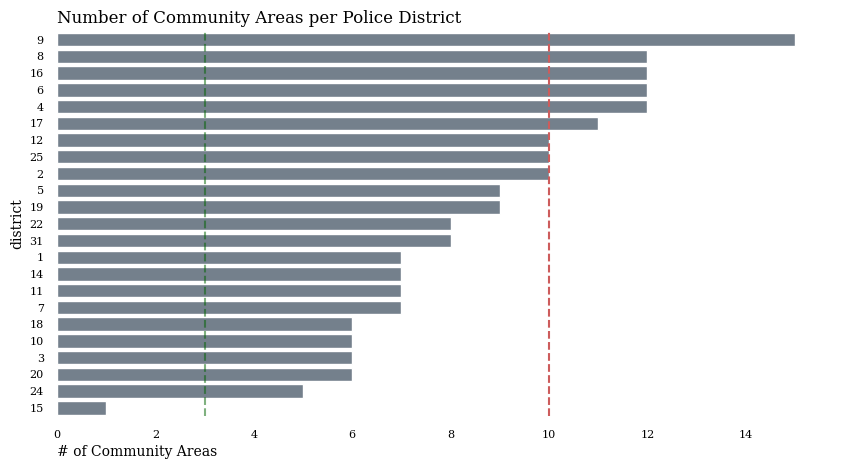

In [ ]:
s = grp_comm_district.copy()

sns.barplot(
    data=s,
    y='district',
    x='area_count',
    color='slategrey',
    order=s.sort_values('area_count', ascending=False)['district']
)

plt.axvline(x=10, ls='--', color='indianred')
plt.axvline(x=3, ls='--', color='darkgreen', alpha=.5)

plt.title('Number of Community Areas per Police District', loc='left')
plt.xlabel('# of Community Areas', loc='left')
plt.box(False)

plt.savefig(f'{img_path}/fig01.png', dpi=300)

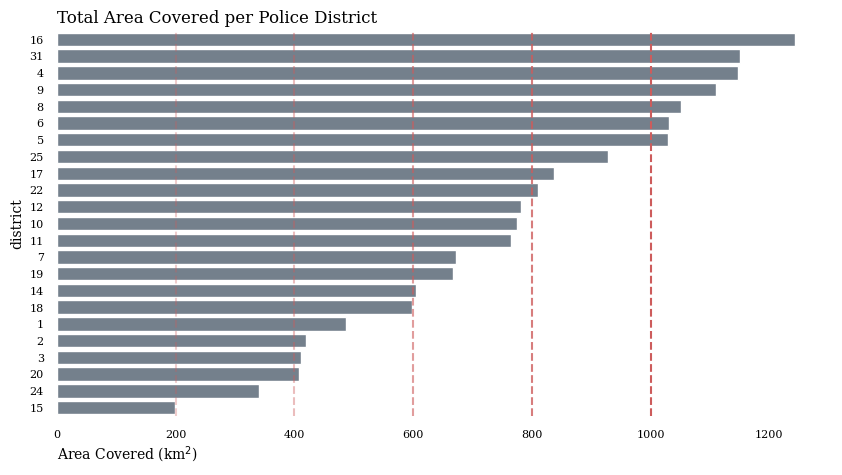

In [59]:
s = grp_comm_district.copy()

sns.barplot(
    data=s,
    y='district',
    x='total_cm_area',
    color='slategrey',
    order=s.sort_values('total_cm_area', ascending=False)['district']
)

plt.axvline(x=1_000, ls='--', color='indianred')
plt.axvline(x=800, ls='--', color='indianred', alpha=.8)
plt.axvline(x=600, ls='--', color='indianred', alpha=.6)
plt.axvline(x=400, ls='--', color='indianred', alpha=.4)
plt.axvline(x=200, ls='--', color='indianred', alpha=.3)

plt.title('Total Area Covered per Police District', loc='left')
plt.xlabel('Area Covered (km$^2$)', loc='left')
plt.box(False)

plt.savefig(f'{img_path}/fig02.png', dpi=300)

## Feature Engineering

### Grouping Primary Type
We shall consider two main groups of criminal activity, based on their behavior:

1. General Theft, concerned more on non-aggressive or property focused behavior;

2. General Assault, concerned on violent and aggressive offenses.

In [24]:
colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT

In [78]:
df_crime = df_crime.drop(
    df_crime[~df_crime['primary_type'].isin(
        gen_theft + gen_aslt
    )].index
)

df_crime['crime_group'] = df_crime['primary_type'].apply(
    lambda x: 'THFT' if x in gen_theft else 'ASLT'
)

df_crime = df_crime.drop(columns=['primary_type']).copy()

# sanity check
print(
    f"There are {df_crime['crime_group'].isnull().sum()} unclassified activities"
)

df_crime['crime_group'].value_counts()

There are 0 unclassified activities


crime_group
ASLT    427096
THFT    389316
Name: count, dtype: int64

### Crime Distance From Station: Average, Closest and Farther
With the latitude and longitude information, from both crime and police station, we can calculate the average distance whereby a crime has occurred and, furthermore, the closest and farther distance from a police station. This may shed light as to whether a police station alludes to a sign of protection. We can also ask if the ASLT average distance is statistically greater than that of THFT.

#### Median Distance
We start by merging the crime dataframe with the stations dataframe on the district key. Some missing values for latitude/longitude appear and, as they represent a very small percentage of the total, they will be dropped.

In [79]:
# to avoid losing the index when performing the merge operation
# we save it as a column before the merge
df_crime['date'] = df_crime.index

df_crime = df_crime.merge(
    df_stations.drop(columns=['district_name']),
    how='left',
    on='district'
)

df_crime = df_crime.set_index('date')

df_crime = df_crime[~df_crime['station_lat'].isna()].copy()
df_crime.head()

,id,arrest,domestic,district,community_area,crime_lat,crime_lon,crime_group,station_lat,station_lon
date,,,,,,,,,,
2022-01-01 00:03:00,12581802,0,0,10,29,41.863540,-87.728763,ASLT,41.856685,-87.708382
2022-01-01 00:04:00,12582232,0,0,12,28,41.884630,-87.670621,ASLT,41.862977,-87.656973
2022-01-01 00:05:00,12582704,0,0,9,61,41.813152,-87.669950,ASLT,41.837394,-87.646408
2022-01-01 00:05:00,12581815,0,0,11,26,41.883342,-87.727544,ASLT,41.873582,-87.705488
2022-01-01 00:05:00,12582341,0,0,4,48,41.734336,-87.580512,ASLT,41.707933,-87.568349


We then apply the *Haversine distance* to obtain the `crime_distance` variable. It is interesting to note that an outlier arises from the THFT crime group regarding a crime that has occurred at 679 km from its registered police district. As later we will train a K-Means model, which is heavily susceptible to outliers, we will rettain only those crimes with `crime_distance` $<$ 100.

The descriptive analysis suggests a very small difference between crime groups, wherein we confirm it by the histplot later on.

In [80]:
df_crime["crime_distance"] = df_crime.apply(
    lambda row: f.haversine_dist(
        row["crime_lat"],
        row["crime_lon"],
        row["station_lat"],
        row["station_lon"]
    ),
    axis=1
)

df_crime = df_crime.query('crime_distance < 100').copy()

print('Statistics about ASLT')
display(
    df_crime[['crime_group', 'crime_distance']]\
        .query('crime_group == "ASLT"')\
        .describe()
)

print('\nStatistics about THFT')
display(
    df_crime[['crime_group', 'crime_distance']]\
        .query('crime_group == "THFT"')\
        .describe()
)

Statistics about ASLT


,crime_distance
count,427076.000000
mean,2.277475
std,1.413172
min,0.003357
25%,1.271415
50%,2.032398
75%,3.062531
max,14.130729



Statistics about THFT


,crime_distance
count,389296.000000
mean,2.312946
std,1.415683
min,0.012172
25%,1.337671
50%,2.079268
75%,3.028053
max,14.127277


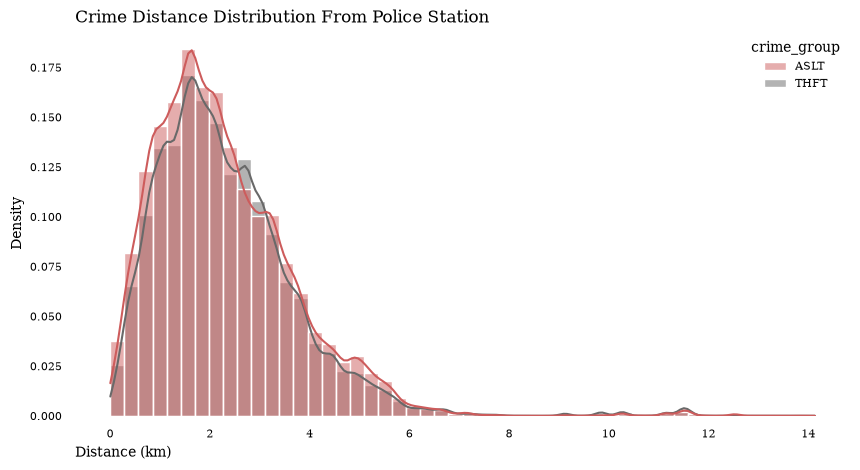

In [81]:
sns.histplot(
    data=df_crime,
    x='crime_distance',
    stat='density',
    hue='crime_group',
    palette=colors,
    kde=True,
    bins=50
);
plt.title('Crime Distance Distribution From Police Station', loc='left')
plt.xlabel('Distance (km)', loc='left')
plt.ylabel('Density')
plt.box(False)

plt.savefig(f'{img_path}/fig03.png', dpi=300)

Looking at the median crime distance per district, we observe that the first four districts stand out, which could indicate important operational patterns, such as:

- Station placement may be suboptimal: police station might be far away from where crimes tend to occur, also, a single station may not be sufficient to cover all hot zones efficiently;
- These districts may cover larger or less densely populated areas, like industrial zones, parks or airport-adjacent areas, such that crimes are occurring near the edges of the district while the station is located near the center;
- Higher distances could be correlated with slower response times, lower arrest rates and lower police presence, especially if they also have higher crime rates.

The latter suggest we analyse `crime_distance` vs `arrest_rate` and/or `domestic_rate`.

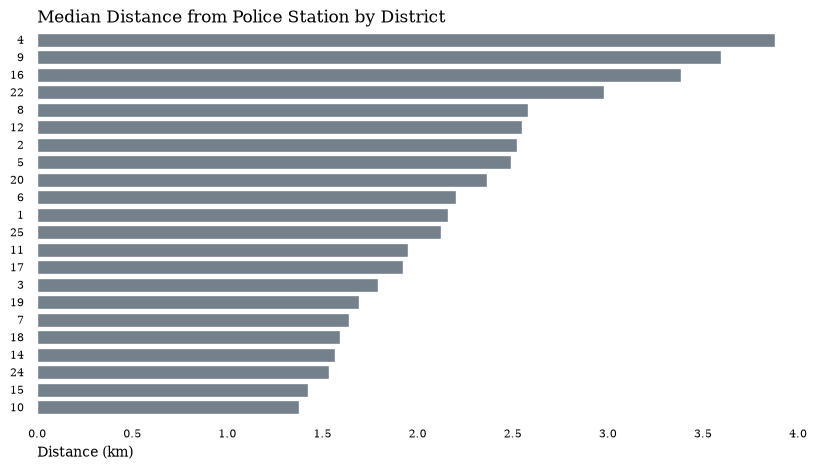

In [82]:
grp_crime = df_crime\
    .groupby(['district'])\
    .agg(
        total=('id', 'count'),
        md_distance=('crime_distance', 'median'),
        std_distance=('crime_distance', 'std')
    )\
    .reset_index(drop=False)

sns.barplot(
    data=grp_crime,
    y='district',
    x='md_distance',
    color='slategrey',
    order=grp_crime.sort_values('md_distance', ascending=False)['district']
);
plt.title('Median Distance from Police Station by District', loc='left')
plt.xlabel('Distance (km)', loc='left')
plt.ylabel('')
plt.box(False)

plt.savefig(f'{img_path}/fig04.png', dpi=300)

#### Minimum Distance
The minimum distance analysis is very similar to `crime_distance`, since in 74% of the cases, `crime_distance` $=$ `min_dist_station`, implying the police station already to be the closest. This also entails 88% of correlation between them.

In [83]:
%%time
df_ = df_stations.query('district != "0"').copy()

df_crime['min_dist_station'] = df_crime.apply(
    lambda r: f.get_min_distance(
        r['crime_lat'],
        r['crime_lon'],
        df_
    ),
    axis=1
)

CPU times: user 5min 31s, sys: 3.05 s, total: 5min 34s
Wall time: 5min 34s


#### Max Distance
We see from the distribution that `max_dist_station` is wider than the others, with its maximum at 44 km and its minimum at 17 km. Moreover, as `min_dist_station` and `crime_distance` are very similar and the correlation of the latter between `max_dist_station` is smaller, we will drop `min_dist_station` from the analysis.

In [84]:
%%time
df_ = df_stations.query('district != "0"').copy()

df_crime['max_dist_station'] = df_crime.apply(
    lambda r: f.get_max_distance(
        r['crime_lat'],
        r['crime_lon'],
        df_
    ),
    axis=1
)

CPU times: user 5min 30s, sys: 2.6 s, total: 5min 33s
Wall time: 5min 33s


In [85]:
display(
    df_crime[['crime_distance', 'min_dist_station', 'max_dist_station']].corr()
)

display(
    df_crime[['crime_distance', 'min_dist_station', 'max_dist_station']].describe()
)

,crime_distance,min_dist_station,max_dist_station
crime_distance,1.000000,0.887369,0.224489
min_dist_station,0.887369,1.000000,0.287638
max_dist_station,0.224489,0.287638,1.000000


,crime_distance,min_dist_station,max_dist_station
count,816372.000000,816372.000000,816372.000000
mean,2.294390,2.022370,26.496263
std,1.414480,1.211734,4.913941
min,0.003357,0.003357,17.334664
25%,1.302644,1.257998,22.572479
50%,2.055620,1.891550,25.823615
75%,3.045856,2.536841,29.810919
max,14.130729,14.130729,44.532111


From the distributions below, we see no significant distinction between the crime groups.

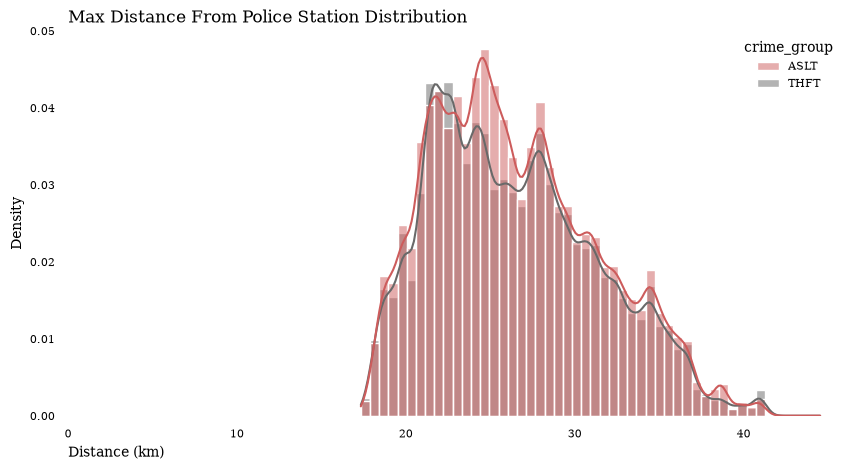

In [86]:
sns.histplot(
    data=df_crime,
    x='max_dist_station',
    stat='density',
    hue='crime_group',
    palette=colors,
    kde=True,
    bins=50
);
plt.title('Max Distance From Police Station Distribution', loc='left')
plt.xlabel('Distance (km)', loc='left')
plt.ylabel('Density')
plt.xlim(0)
plt.box(False)

plt.savefig(f'{img_path}/fig05.png', dpi=300)

We next merge `df_crime` with `grp_comm_district`, using district as key, to get information about community areas inside each district, and, afterwards, merge the former with `df_census`, using community area as key, to get further information on community areas.

In [87]:
df_crime['date'] = df_crime.index

df_crime = df_crime.merge(
    grp_comm_district.drop(columns=['area_count']),
    how='left',
    on='district'
)

df_crime = df_crime.merge(
    df_census,
    how='left',
    on='community_area',
)

df_crime = df_crime.drop(
    columns=[
        'station_lat',
        'station_lon'
    ]
)

df_crime = df_crime.set_index('date')

In [89]:
df_crime.to_csv(f'{slv_path}/df_crime_final.csv', index=True)

So far, we have:

In [ ]:
df_crime = pd.read_csv(
    f'{slv_path}/df_crime_final.csv',
    index_col='date',
    parse_dates=True
)

We can consider the daily statistics for `df_crime` so as to save it in the gold layer for further inspection later.

In [90]:
df_crime['ddate'] = df_crime.index.date

In [91]:
daily_df = df_crime\
    .groupby(['ddate', 'crime_group'])\
    .agg(
        count=('id', 'count'),
        domestic_count=('domestic', 'sum'),
        arrest_count=('arrest', 'sum'),
        domestic_rate=('domestic', 'mean'),
        arrest_rate=('arrest', 'mean'),
        avg_dist=('crime_distance', 'mean'),
        avg_max_dist=('max_dist_station', 'mean'),
        avg_cm_area=('avg_cm_area', 'mean'),
        avg_total_area=('total_cm_area', 'mean'),
        avg_cm_len=('avg_cm_len', 'mean'),
        total_cm_len=('total_cm_len', 'mean'),
        avg_pct_housing=('pct_housing_crowded', 'mean'),
        avg_pct_below_pvty=('pct_hh_below_pvty', 'mean'),
        avg_pct_unemployed=('pct_16_unemployed', 'mean'),
        avg_pct_without_hsd=('pct_25_without_hsd', 'mean'),
        avg_pct_dependents=('pct_dependents', 'mean'),
        avg_per_capita_income=('per_capita_income', 'mean'),
        avg_hardship_index=('hardship_index', 'mean'),
    ).reset_index()

daily_df = daily_df.set_index('ddate')
daily_df.head()

,crime_group,count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_area,avg_total_area,avg_cm_len,total_cm_len,avg_pct_housing,avg_pct_below_pvty,avg_pct_unemployed,avg_pct_without_hsd,avg_pct_dependents,avg_per_capita_income,avg_hardship_index
ddate,,,,,,,,,,,,,,,,,,,
2022-01-01,ASLT,263,116,57,0.441065,0.216730,2.214720,26.049704,92.469085,738.662694,45.620041,377.235712,0.056852,0.254038,0.178878,0.218768,0.355471,24402.053232,57.262357
2022-01-01,THFT,143,12,9,0.083916,0.062937,2.061607,25.451131,91.272314,755.771420,45.792829,388.545827,0.041650,0.223965,0.146650,0.169930,0.316112,36319.097902,42.853147
2022-01-02,ASLT,177,65,27,0.367232,0.152542,2.274763,26.771035,91.847275,790.098471,45.300288,396.684818,0.056994,0.252723,0.172898,0.213797,0.353893,24898.135593,56.435028
2022-01-02,THFT,161,6,8,0.037267,0.049689,2.339852,26.221450,86.989042,711.092994,45.073807,372.186507,0.040180,0.205354,0.136950,0.150857,0.306826,36713.279503,37.161491
2022-01-03,ASLT,156,56,28,0.358974,0.179487,2.332642,26.988741,91.780599,781.285014,45.296635,393.847314,0.053795,0.262782,0.180615,0.209218,0.362186,23182.250000,57.205128


In [92]:
daily_df.to_csv(f'{gld_path}/daily_crime.csv', index=True)

In [ ]:
daily_df = pd.read_csv(
    f'{gld_path}/daily_crime.csv',
    index_col='ddate',
    parse_dates=True
)

,crime_group,count,domestic_count,arrest_count,domestic_rate,arrest_rate,avg_dist,avg_max_dist,avg_cm_area,avg_total_area,avg_cm_len,total_cm_len,avg_pct_housing,avg_pct_below_pvty,avg_pct_unemployed,avg_pct_without_hsd,avg_pct_dependents,avg_per_capita_income,avg_hardship_index
ddate,,,,,,,,,,,,,,,,,,,
2022-06-15,ASLT,26,8,8,0.307692,0.307692,2.494739,25.455089,85.100167,789.815882,43.748691,408.294235,0.059077,0.282423,0.201462,0.225808,0.367846,19986.076923,62.961538
2022-06-15,THFT,8,1,0,0.125000,0.000000,2.148291,25.734895,80.488894,730.168285,42.983247,389.746663,0.031500,0.258750,0.163625,0.143375,0.316625,32922.250000,43.000000
2022-06-16,ASLT,284,103,53,0.362676,0.186620,2.229185,26.714702,93.892376,754.560136,45.885633,378.947228,0.052423,0.257824,0.170930,0.202754,0.350525,25406.091549,54.873239
2022-06-16,THFT,206,8,12,0.038835,0.058252,2.290899,25.800435,86.200286,718.949872,44.824618,378.119251,0.040888,0.218913,0.142058,0.164359,0.314524,34218.189320,40.650485
2022-06-17,ASLT,306,97,71,0.316993,0.232026,2.378555,26.548815,89.850901,780.389186,44.978737,395.876061,0.054833,0.255863,0.169647,0.215180,0.350206,24027.258170,55.526144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-29,THFT,211,6,20,0.028436,0.094787,2.426231,27.019182,88.582168,764.432203,45.509161,399.775393,0.045664,0.224863,0.148114,0.183787,0.326488,31235.620853,45.383886
2025-12-30,ASLT,169,63,49,0.372781,0.289941,2.387442,26.417581,90.656926,770.359684,44.947743,392.094894,0.054142,0.258059,0.177692,0.220497,0.357000,24112.136095,57.390533
2025-12-30,THFT,192,8,24,0.041667,0.125000,2.341834,26.285639,88.457288,761.414513,45.518031,394.572814,0.043151,0.212073,0.136208,0.168505,0.308776,35662.156250,39.260417


With `daily_df`, we are able to see the evolution of domestic and arrest count, for instance. We leave comments and analysis for the next notebook.

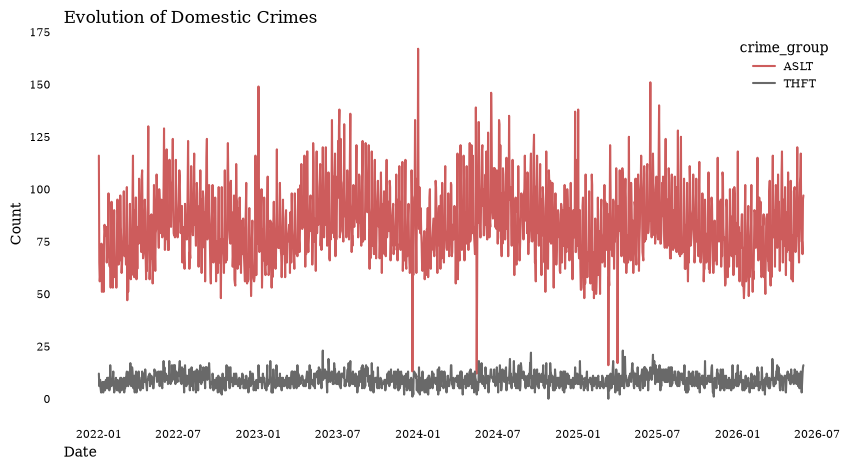

In [93]:
plt.title('Evolution of Domestic Crimes', loc='left')
plt.xlabel('Date', loc='left')
plt.ylabel('Count')
plt.box(False)
sns.lineplot(
    data=daily_df,
    x='ddate',
    y='domestic_count',
    hue='crime_group',
    palette=colors
);

plt.savefig(f'{img_path}/fig06.png', dpi=300)

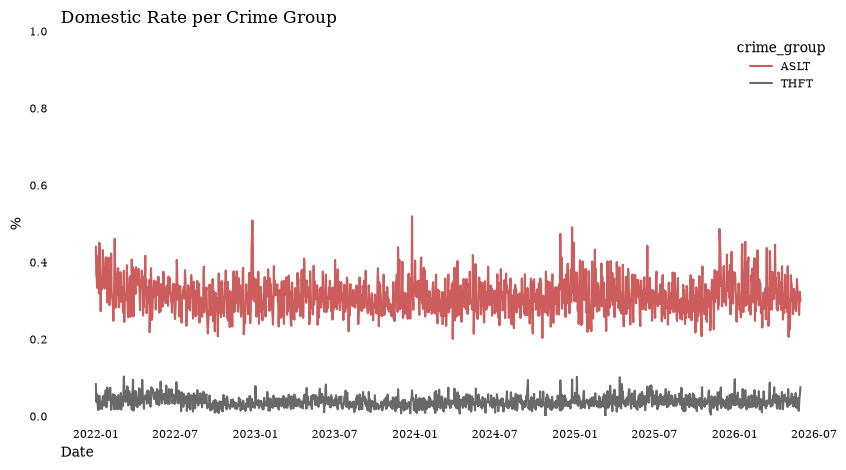

In [94]:
plt.title('Domestic Rate per Crime Group', loc='left')
plt.xlabel('Date', loc='left')
plt.ylabel('%')
plt.ylim(0, 1)
plt.box(False)
sns.lineplot(
    data=daily_df,
    x='ddate',
    y='domestic_rate',
    hue='crime_group',
    palette=colors
);

plt.savefig(f'{img_path}/fig07.png', dpi=300)